Completed 25/500
Completed 50/500
Completed 75/500
Completed 100/500
Completed 125/500
Completed 150/500
Completed 175/500
Completed 200/500
Completed 225/500
Completed 250/500
Completed 275/500
Completed 300/500
Completed 325/500
Completed 350/500
Completed 375/500
Completed 400/500
Completed 425/500
Completed 450/500
Completed 475/500
Completed 500/500
MDE ≈ 3.183% (alpha=0.05, target power=80.0%)


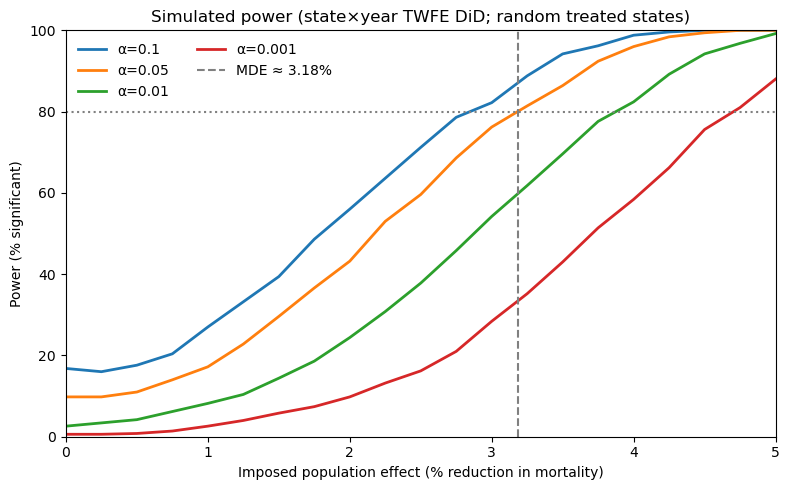

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

# ----------------------------
# SETTINGS
# ----------------------------
DATA_PATH = "Multiple Cause of Death, 1999-2020.csv"
N_SIM = 500
N_TREATED = 23

FIRST_YEAR, LAST_YEAR = 2006, 2011          # pre: 2006-2010, post: 2011-2013
EFFECT_GRID = np.arange(0, 0.05001, 0.0025) # 0% to 5% by 0.25%
ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05

rng = np.random.default_rng(1234)

# ----------------------------
# LOAD + CLEAN
# ----------------------------
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df.dropna(subset=["deaths", "population"])

df = df[(df["year"] >= FIRST_YEAR) & (df["year"] < 2014)].copy()
df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)

# indices for fast group ops
state_codes = np.sort(df["state_id"].unique())
year_vals = np.sort(df["year"].unique())
state_to_idx = {s:i for i,s in enumerate(state_codes)}
year_to_idx  = {y:i for i,y in enumerate(year_vals)}

s = df["state_id"].map(state_to_idx).to_numpy()
tt = df["year"].map(year_to_idx).to_numpy()
S, T = len(state_codes), len(year_vals)

deaths0 = df["deaths"].to_numpy().astype(int)
pop = df["population"].to_numpy().astype(float)
w = pop
post = (df["year"].to_numpy() >= LAST_YEAR).astype(int)

# ----------------------------
# TWFE (1 regressor) with cluster-by-state variance
# ----------------------------
def twoway_demean(x):
    x_bar = (w * x).sum() / w.sum()
    xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
    xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
    return x - xs[s] - xt[tt] + x_bar

def twfe_beta_se(y, d):
    yt = twoway_demean(y)
    dt = twoway_demean(d)

    bread = np.sum(w * dt * dt)
    beta = np.sum(w * dt * yt) / bread

    u = yt - beta * dt
    score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
    var_beta = np.sum(score_g**2) / (bread**2)

    return beta, np.sqrt(var_beta), (S - 1)

# ----------------------------
# SIMULATE p-values for each effect size
# ----------------------------
J = len(EFFECT_GRID)
pvals = np.empty((N_SIM, J))

state_idx = np.arange(S)

for k in range(N_SIM):
    treated_states = rng.choice(state_idx, size=N_TREATED, replace=False)
    treated = np.isin(s, treated_states).astype(int)
    d = treated * post  # TreatPost regressor

    for j, eff in enumerate(EFFECT_GRID):
        removed = rng.binomial(n=deaths0, p=eff) * d
        deaths_eff = deaths0 - removed
        y = np.log((deaths_eff / pop) * 100000.0 + 1.0)

        beta, se_beta, df_t = twfe_beta_se(y, d)

        # Stata uses nlcom 100*(exp(beta)-1)
        b_pct = 100.0 * (np.exp(beta) - 1.0)
        se_pct = 100.0 * np.exp(beta) * se_beta
        tstat = b_pct / se_pct
        pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    if (k + 1) % 25 == 0:
        print(f"Completed {k+1}/{N_SIM}")

# ----------------------------
# POWER TABLE
# ----------------------------
out = pd.DataFrame({"effect_size_pct": EFFECT_GRID * 100})

for a in ALPHAS:
    out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

# ----------------------------
# MDE (linear interpolation around 80% power at alpha=0.05)
# ----------------------------
powcol = f"power_{ALPHA_FOR_MDE:.3f}"
gap = np.abs(out[powcol] - TARGET_POWER)
i1, i2 = np.argsort(gap.values)[:2]
x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
y1, y2 = out.loc[[i1, i2], powcol].values

m = (y2 - y1) / (x2 - x1)
c = y1 - m * x1
mde = (TARGET_POWER - c) / m

print(f"MDE ≈ {mde:.3f}% (alpha={ALPHA_FOR_MDE}, target power={TARGET_POWER}%)")

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(8, 5))
for a in ALPHAS:
    plt.plot(out["effect_size_pct"], out[f"power_{a:.3f}"], lw=2, label=f"α={a:g}")

plt.axvline(mde, color="gray", ls="--", lw=1.5, label=f"MDE ≈ {mde:.2f}%")
plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5)

plt.ylim(0, 100)
plt.xlim(0, out["effect_size_pct"].max())
plt.xlabel("Imposed population effect (% reduction in mortality)")
plt.ylabel("Power (% significant)")
plt.title("Simulated power (state×year TWFE DiD; random treated states)")
plt.legend(frameon=False, ncols=2)
plt.tight_layout()
plt.show()


In [2]:
def mde_from_power_curve(out, alpha, target_power=80.0):
    """
    out must have:
      - out["effect_size_pct"]
      - out[f"power_{alpha:.3f}"]
    Returns interpolated MDE in percent units.
    """
    col = f"power_{alpha:.3f}"
    gap = np.abs(out[col] - target_power)
    i1, i2 = np.argsort(gap.values)[:2]

    x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
    y1, y2 = out.loc[[i1, i2], col].values

    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return float((target_power - b) / m)


mde_table = []
for a in ALPHAS:
    mde_pct = mde_from_power_curve(out, a, target_power=TARGET_POWER)
    mde_table.append({"alpha": a, "mde_pct": mde_pct})
mde_table = pd.DataFrame(mde_table)
print(mde_table)

   alpha   mde_pct
0  0.100  2.847222
1  0.050  3.182692
2  0.010  3.875000
3  0.001  4.703704


In [3]:
import numpy as np
import pandas as pd

TARGET_POWER = 80.0
ALPHAS = [0.10, 0.05, 0.01, 0.001]

# --- CBO constants for 2022 ---
N_pop_cbo_2022 = 284_000_000  # July 2012 Table 3 TOTAL nonelderly in 2022

# --- CBO coverage increments (Table A-2, Feb 2013 Outlook) ---
dN_aug = 11_000_000
dN_feb = 12_000_000

# --- CBO 10-year Medicaid+CHIP outlays (billions) (Table A-2) ---
outlays_aug_B = 643e9
outlays_feb_B = 550e9

# crude per-enrollee-year costs over 10 years
c_aug = outlays_aug_B / (dN_aug * 10)
c_feb = outlays_feb_B / (dN_feb * 10)

# a "fixed cost" option (pick one; or use a grid)
c_fixed = 6000.0

# kappa grid (try multiple)
kappa_grid = [0.05, 0.10, 0.20]  # = r*tau

rows = []
for a in ALPHAS:
    mde_pct = mde_from_power_curve(out, a, target_power=TARGET_POWER)  # percent
    mde = mde_pct / 100.0  # share

    for kappa in kappa_grid:
        f_min = mde / kappa
        dN_min = f_min * N_pop_cbo_2022

        for cost_mode, c in [("fixed", c_fixed), ("cbo_aug", c_aug), ("cbo_feb", c_feb)]:
            B_min = c * dN_min

            rows.append({
                "alpha": a,
                "target_power": TARGET_POWER,
                "mde_pct": mde_pct,
                "kappa": kappa,
                "f_min": f_min,
                "N_pop": N_pop_cbo_2022,
                "dN_min": dN_min,
                "cost_mode": cost_mode,
                "cost_per_enrollee_year": c,
                "budget_min": B_min
            })

alpha_budget = pd.DataFrame(rows)
alpha_budget.to_csv("alpha_to_budget.csv", index=False)

print("c_aug =", c_aug, "c_feb =", c_feb)
alpha_budget.head()

c_aug = 5845.454545454545 c_feb = 4583.333333333333


,alpha,target_power,mde_pct,kappa,f_min,N_pop,dN_min,cost_mode,cost_per_enrollee_year,budget_min
0,0.1,80.0,2.847222,0.05,0.569444,284000000,1.617222e+08,fixed,6000.000000,9.703333e+11
1,0.1,80.0,2.847222,0.05,0.569444,284000000,1.617222e+08,cbo_aug,5845.454545,9.453399e+11
2,0.1,80.0,2.847222,0.05,0.569444,284000000,1.617222e+08,cbo_feb,4583.333333,7.412269e+11
3,0.1,80.0,2.847222,0.10,0.284722,284000000,8.086111e+07,fixed,6000.000000,4.851667e+11
4,0.1,80.0,2.847222,0.10,0.284722,284000000,8.086111e+07,cbo_aug,5845.454545,4.726699e+11


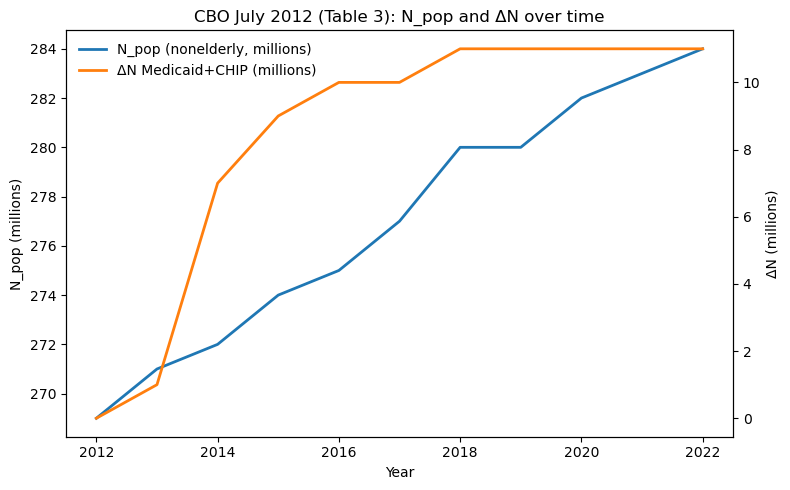

    year  N_pop_millions  dN_medicaid_millions         f
0   2012           269.0                   0.0  0.000000
1   2013           271.0                   1.0  0.003690
2   2014           272.0                   7.0  0.025735
3   2015           274.0                   9.0  0.032847
4   2016           275.0                  10.0  0.036364
5   2017           277.0                  10.0  0.036101
6   2018           280.0                  11.0  0.039286
7   2019           280.0                  11.0  0.039286
8   2020           282.0                  11.0  0.039007
9   2021           283.0                  11.0  0.038869
10  2022           284.0                  11.0  0.038732


In [4]:
years = np.arange(2012, 2023)

# July 2012 Table 3: TOTAL nonelderly population (millions)
N_pop_m = np.array([269, 271, 272, 274, 275, 277, 280, 280, 282, 283, 284], dtype=float)

# July 2012 Table 3: Change in coverage Medicaid and CHIP under ACA (millions)
# 2012 is "*", treat as 0 for plotting; feel free to set NaN instead.
dN_m = np.array([0, 1, 7, 9, 10, 10, 11, 11, 11, 11, 11], dtype=float)

panel = pd.DataFrame({
    "year": years,
    "N_pop_millions": N_pop_m,
    "dN_medicaid_millions": dN_m,
})
panel["f"] = panel["dN_medicaid_millions"] / panel["N_pop_millions"]

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(panel["year"], panel["N_pop_millions"], lw=2, label="N_pop (nonelderly, millions)")
ax1.set_ylabel("N_pop (millions)")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(panel["year"], panel["dN_medicaid_millions"], lw=2, color="C1", label="ΔN Medicaid+CHIP (millions)")
ax2.set_ylabel("ΔN (millions)")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, frameon=False, loc="upper left")

plt.title("CBO July 2012 (Table 3): N_pop and ΔN over time")
plt.tight_layout()
plt.show()

print(panel)

In [5]:
# Choose CBO N_pop for 2022
N_pop_2022 = 284_000_000

# choose kappa values to try (r*tau)
kappa_grid = [0.05, 0.10, 0.20]

# choose cost per enrollee-year (either fixed or CBO-implied)
c_fixed = 6000

rows = []
for a in ALPHAS:
    mde_pct = mde_from_power_curve(out, a, target_power=TARGET_POWER)
    mde = mde_pct / 100.0  # convert % to share

    for kappa in kappa_grid:
        f_min = mde / kappa
        dN_min = f_min * N_pop_2022
        B_min = c_fixed * dN_min

        rows.append({
            "alpha": a,
            "target_power": TARGET_POWER,
            "mde_pct": mde_pct,
            "kappa": kappa,
            "f_min": f_min,
            "N_pop_2022": N_pop_2022,
            "dN_min": dN_min,
            "cost_per_enrollee_year": c_fixed,
            "budget_min": B_min
        })

alpha_budget = pd.DataFrame(rows)
alpha_budget

,alpha,target_power,mde_pct,kappa,f_min,N_pop_2022,dN_min,cost_per_enrollee_year,budget_min
0,0.100,80.0,2.847222,0.05,0.569444,284000000,1.617222e+08,6000,9.703333e+11
1,0.100,80.0,2.847222,0.10,0.284722,284000000,8.086111e+07,6000,4.851667e+11
2,0.100,80.0,2.847222,0.20,0.142361,284000000,4.043056e+07,6000,2.425833e+11
3,0.050,80.0,3.182692,0.05,0.636538,284000000,1.807769e+08,6000,1.084662e+12
4,0.050,80.0,3.182692,0.10,0.318269,284000000,9.038846e+07,6000,5.423308e+11
5,0.050,80.0,3.182692,0.20,0.159135,284000000,4.519423e+07,6000,2.711654e+11
6,0.010,80.0,3.875000,0.05,0.775000,284000000,2.201000e+08,6000,1.320600e+12
7,0.010,80.0,3.875000,0.10,0.387500,284000000,1.100500e+08,6000,6.603000e+11
8,0.010,80.0,3.875000,0.20,0.193750,284000000,5.502500e+07,6000,3.301500e+11
9,0.001,80.0,4.703704,0.05,0.940741,284000000,2.671704e+08,6000,1.603022e+12
